# 运算
利用skimage库，读取彩色图像A1和A2，对A1图像进行幂次为0.6的变换得到图像B，用图像A1减去图像B得到图像C,用图像A1加上图像A2得到图像D，  
计算并输出图像A1和B的PSNR,SSIM,显示A1、A2、B、C、D图（输出的文件名和展示效果按下图样例所示），写出实现上述要求的python程序  
注意：由于调用库函数和思路的差异，评测以实现效果展示为主，PSNR、SSIM为辅  

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

# 读取彩色图像A1和A2
A1 = cv2.imread('/data/bigfiles/A1.jpg')  
A2 = cv2.imread('/data/bigfiles/A2.png')  

# 将BGR转换为RGB（因为OpenCV默认读取为BGR格式）
A1 = cv2.cvtColor(A1, cv2.COLOR_BGR2RGB)
A2 = cv2.cvtColor(A2, cv2.COLOR_BGR2RGB)

# 调整A2的尺寸与A1一致
if A1.shape != A2.shape:
    A2 = cv2.resize(A2, (A1.shape[1], A1.shape[0]))

# 对A1进行幂次变换（gamma=0.6变亮）
B = np.power(A1.astype(np.float32) / 255.0, 0.6) * 255.0
# A1.astype(np.float32) 将数据类型从通常的 uint8（无符号整数，范围 0-255）转换为 float32（32 位浮点数）。对于后续的幂次运算是必要的
# / 255.0 归一化图像数据
# np.power(,0.6)幂次变换
B = B.astype(np.uint8)

# 计算图像C = A1 - B（注意处理负值）
C = A1.astype(np.int16) - B.astype(np.int16)
C = np.clip(C, 0, 255).astype(np.uint8) # 使用 np.clip 函数将 C 中的像素值限制在 0 到 255 的范围内

# 计算图像D = A1 + A2（注意处理溢出）
D = cv2.add(A1.astype(np.uint8), A2.astype(np.uint8))

# 计算PSNR和SSIM（需要将图像转换为float32并归一化）
psnr_value = psnr(A1, B, data_range=255)
ssim_value = ssim(A1, B, data_range=255, multichannel=True)# 多通道

print(f"PSNR between A1 and B: {psnr_value:.2f} dB")
print(f"SSIM between A1 and B: {ssim_value:.4f}")

# 显示图像
plt.figure(figsize=(15, 10))

# 显示A1
plt.subplot(2, 3, 1)
plt.imshow(A1)
plt.title('A1')
plt.axis('off')

# 显示A2
plt.subplot(2, 3, 2)
plt.imshow(A2)
plt.title('A2')
plt.axis('off')

# 显示B
plt.subplot(2, 3, 3)
plt.imshow(B)
plt.title('B (A1^0.6)')
plt.axis('off')

# 显示C
plt.subplot(2, 3, 4)
plt.imshow(C)
plt.title('C (A1-B)')
plt.axis('off')

# 显示D
plt.subplot(2, 3, 5)
plt.imshow(D)
plt.title('D (A1+A2)')
plt.axis('off')

plt.tight_layout()
plt.show()

## 简化
利用skimage库，读取彩色图像ImageA1和mageA2，对A1图像进行幂次变换（幂次大于1）得到图像B，用图像A1减去图像B得到图像C,用图像A1加上图像A2得到图像D，  
计算图像A1和B的PSNR,SSIM并显示A1、A2、B、C、D图，  

In [ ]:
import numpy as np
import cv2
from matplotlib import pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

A1=cv2.imread('/data/bigfiles/ImageA1.jpg')
A2=cv2.imread('/data/bigfiles/ImageA2.png')

A1=cv2.cvtColor(A1,cv2.COLOR_BGR2RGB)
A2=cv2.cvtColor(A2,cv2.COLOR_BGR2RGB)

if A1.shape != A2.shape:
    A2=cv2.resize(A2,(A1.shape[1],A1.shape[0])) ##  转同一大小

B=np.power(A1.astype(np.float32)/255.0,1.6)*255.0  ## 类型转换
B=B.astype(np.uint8)

C=cv2.subtract(A1,B)
D=cv2.add(A1,A2)

psnr_value = psnr(A1, B)
ssim_value = ssim(A1, B, multichannel=True)  ## 多通道

print(f"A1和B的PSNR: {psnr_value:.2f} dB,SSIM: {ssim_value:.4f}")

plt.figure(figsize=(12,6))

plt.subplot(151)
plt.title('A1')
plt.imshow(A1)
plt.axis('off')

plt.subplot(152)
plt.title('A2')
plt.imshow(A2)
plt.axis('off')

plt.subplot(153)
plt.title('B')
plt.imshow(B)
plt.axis('off')

plt.subplot(154)
plt.title('C')
plt.imshow(C)
plt.axis('off')

plt.subplot(155)
plt.title('D')
plt.imshow(D)
plt.axis('off')

plt.tight_layout()
plt.show()

# 分割
读取一幅蒲公英的RGB彩色图像（文件名为M.jpg），将图像转化到HSV彩色空间，并分割出黄色花朵部分，  
要求显示M原图、R分量图、G分量图、B分量图、HSV图、彩色分割后E图；  
计算并打印出E的像素值总和（输出格式示例为 SUM:123456），写出实现该功能的python程序  

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 读取图像
image = cv2.imread('/data/bigfiles/M.jpg')

# 将BGR图像转换为RGB以适应Matplotlib
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# 分离RGB通道
r, g, b = cv2.split(image_rgb)

# 将图像从BGR转为HSV
hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
# cv2.inRange(src, lowerb, upperb[, dst]) → dst
# 用于在图像中检测特定颜色范围。它通过比较图像中的每个像素值与指定的下限和上限范围来生成一个二值掩码（黑白图像），其中在范围内的像素为白色（255），范围外的像素为黑色（0）


# 定义黄色范围
lower_yellow = np.array([20, 100, 100])
upper_yellow = np.array([30, 255, 255])

# 创建掩码以提取黄色区域
mask = cv2.inRange(hsv_image, lower_yellow, upper_yellow) 

# 使用掩码对原始图像进行操作以获取结果
result = cv2.bitwise_and(image, image, mask=mask) # 将原始图像与掩码进行按位与操作，以提取黄色区域

# 将结果图像转换为RGB以适应Matplotlib
result_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

# 显示原图、R分量图、G分量图、B分量图
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.title('Original Image')
plt.imshow(image_rgb)
plt.axis('off')

plt.subplot(2, 3, 2)
plt.title('Red Channel')
plt.imshow(r, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.title('Green Channel')
plt.imshow(g, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.title('Blue Channel')
plt.imshow(b, cmap='gray')
plt.axis('off')

# 显示HSV图像和分割后的图像
plt.subplot(2, 3, 5)
plt.title('HSV Image')
plt.imshow(cv2.cvtColor(hsv_image, cv2.COLOR_HSV2RGB))
plt.axis('off')

plt.subplot(2, 3, 6)
plt.title('Yellow Segmented Image')
plt.imshow(result_rgb)
plt.axis('off')

# 计算并打印分割后图像的像素值总和
sum_pixels = np.sum(result)
print(f'SUM: {sum_pixels}')

# 显示所有图像
plt.tight_layout()
plt.show()

## 简化
读取一幅蒲公英的彩色图像，将图片中花朵的颜色改变成红色，并分割出花朵部分，  
并显示原图、R分量图、G分量图、B分量图、二值分割结果图、彩色分割后的图像。  

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

img=cv2.imread('/data/bigfiles/dandelion3.jpg') 
img_rgb=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

r,g,b=cv2.split(img_rgb)

img_gray=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
ret,seg=cv2.threshold(img_gray,0,255,cv2.THRESH_OTSU) ##

img_hsv=cv2.cvtColor(img,cv2.COLOR_BGR2HSV) ##
yellow_lower=np.array([20,30,100])
yellow_upper=np.array([30,255,255])
mask=cv2.inRange(img_hsv,yellow_lower,yellow_upper) ##
result=cv2.bitwise_and(img,img,mask=mask)
result=cv2.cvtColor(result,cv2.COLOR_BGR2RGB)

plt.figure(figsize=(15,10))

plt.subplot(231)
plt.title('Original')
plt.imshow(img_rgb)
plt.axis('off')

plt.subplot(232)
plt.title('R')
plt.imshow(r,cmap='gray')
plt.axis('off')

plt.subplot(233)
plt.title('G')
plt.imshow(g,cmap='gray')
plt.axis('off')

plt.subplot(234)
plt.title('B')
plt.imshow(b,cmap='gray')
plt.axis('off')

plt.subplot(235)
plt.title('seg')
plt.imshow(seg,cmap='gray')
plt.axis('off')

plt.subplot(236)
plt.title('cai')
plt.imshow(result)
plt.axis('off')

plt.tight_layout()
plt.show()

# 边缘检测
读取一幅彩色图像R.png，对RGB三个分量分别做水平X和竖直Y方向的梯度边缘检测，然后再合成水平和竖直方向边缘检测的彩色浮雕效果图relief  
计算并输出浮雕效果图的像素和，输出格式示例为SUM：123456。展示原图，水平X和竖直Y方向的梯度边缘检测图和彩色浮雕效果图relief

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 读取图像
image = cv2.imread('/data/bigfiles/R.png')

# 转换为RGB格式
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# 分离RGB通道
r, g, b = cv2.split(image_rgb)

# 计算每个通道的X和Y方向梯度
def compute_gradients(channel):
    grad_x = cv2.Sobel(channel, cv2.CV_64F, 1, 0, ksize=3) # Sobel算子的大小ksize = 3
    grad_y = cv2.Sobel(channel, cv2.CV_64F, 0, 1, ksize=3)
    return grad_x, grad_y

grad_r_x, grad_r_y = compute_gradients(r)
grad_g_x, grad_g_y = compute_gradients(g)
grad_b_x, grad_b_y = compute_gradients(b)

# 合并X和Y方向的梯度
grad_x = cv2.magnitude(grad_r_x, grad_r_y) + cv2.magnitude(grad_g_x, grad_g_y) + cv2.magnitude(grad_b_x, grad_b_y)
grad_y = cv2.magnitude(grad_r_x, grad_r_y) + cv2.magnitude(grad_g_x, grad_g_y) + cv2.magnitude(grad_b_x, grad_b_y)

# 归一化到0-255
grad_x = cv2.normalize(grad_x, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
grad_y = cv2.normalize(grad_y, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# 合并X和Y方向的梯度得到最终的浮雕效果
relief = cv2.addWeighted(grad_x, 0.5, grad_y, 0.5, 0)

# 计算浮雕效果图的像素和
sum_pixels = np.sum(relief)

# 显示原图、X方向、Y方向和合并后的图
plt.figure(figsize=(12, 6))

plt.subplot(2, 2, 1)
plt.title('Original Image')
plt.imshow(image_rgb)
plt.axis('off')

plt.subplot(2, 2, 2)
plt.title('Gradient X Direction')
plt.imshow(grad_x, cmap='gray')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.title('Gradient Y Direction')
plt.imshow(grad_y, cmap='gray')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.title('Relief Effect (X+Y)')
plt.imshow(relief, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

print(f'SUM: {sum_pixels}')


In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

img=cv2.imread('/data/bigfiles/nature2.png')
img_rgb=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
r,g,b=cv2.split(img_rgb)

def gra(channel):
    sobel_x=cv2.Sobel(channel,cv2.CV_64F,1,0,ksize=3)
    sobel_y=cv2.Sobel(channel,cv2.CV_64F,1,0,ksize=3)
    sobel_x_abs=cv2.convertScaleAbs(sobel_x)
    sobel_y_abs=cv2.convertScaleAbs(sobel_y)
    sobel_xy=cv2.addWeighted(sobel_x_abs,0.5,sobel_y_abs,0.5,0)
    return sobel_xy
    
r_sobel=gra(r)
g_sobel=gra(g)
b_sobel=gra(b)
sobel=cv2.addWeighted(r_sobel,0.33,cv2.addWeighted(g_sobel,0.33,b_sobel,0.33,0),0.5,0)
plt.figure(figsize=(12,6))

plt.subplot(151)
plt.title('original')
plt.imshow(img_rgb)
plt.axis('off')

plt.subplot(152)
plt.title('r')
plt.imshow(r_sobel)
plt.axis('off')

plt.subplot(153)
plt.title('g')
plt.imshow(g_sobel)
plt.axis('off')

plt.subplot(154)
plt.title('b')
plt.imshow(b_sobel)
plt.axis('off')

plt.subplot(155)
plt.title('result')
plt.imshow(sobel)
plt.axis('off')

plt.tight_layout()
plt.show()

## 简化
读取一幅彩色图像（nature2.png），对RGB三个分量分别做水平和竖直方向的梯度边缘检测，然后再合成水平和竖直方向边缘检测的彩色图，有浮雕的效果。  

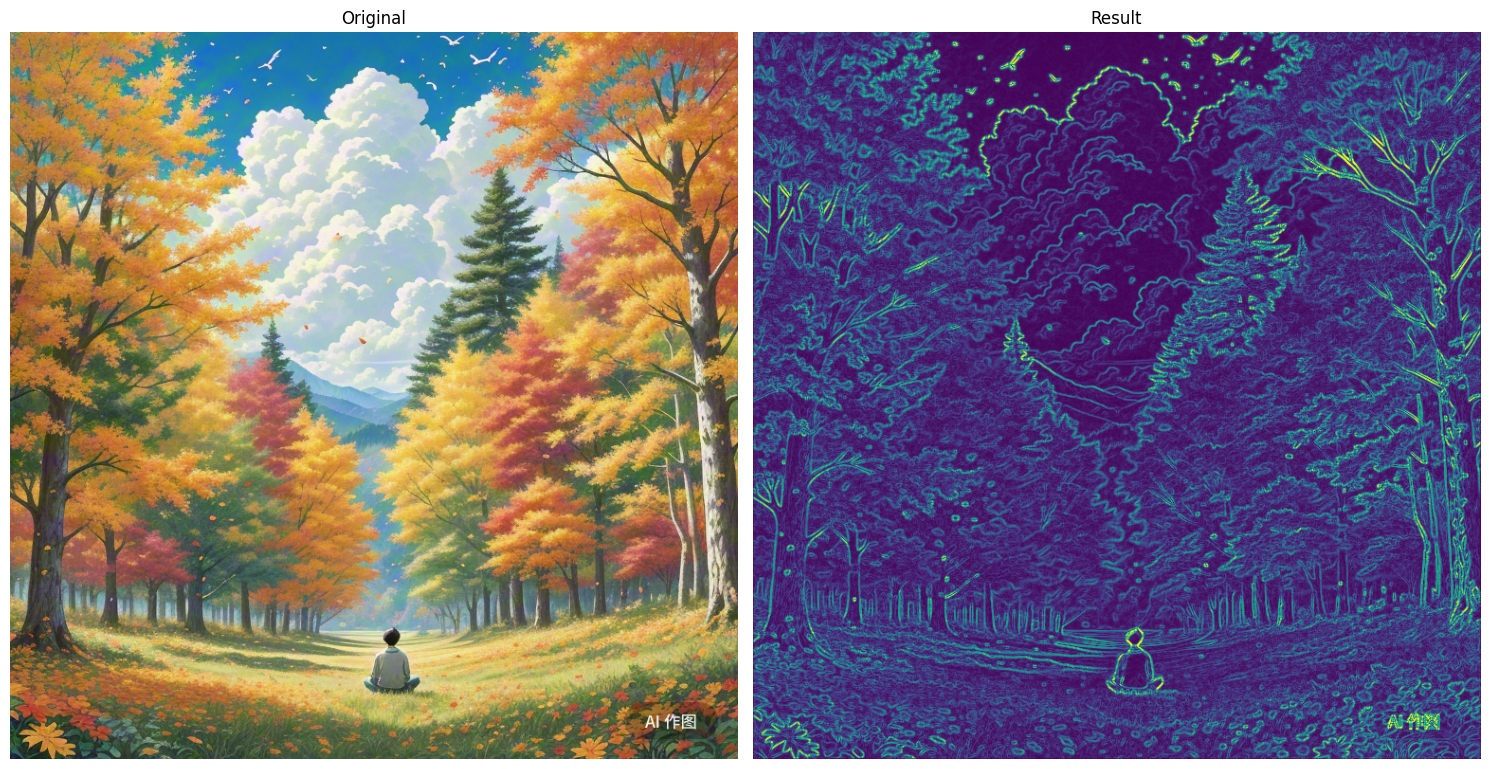

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

img=cv2.imread(r"") 
img_rgb=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
r,g,b=cv2.split(img_rgb)

def gra(channel):
    sobel_x=cv2.Sobel(channel,cv2.CV_64F,1,0,ksize=3)
    sobel_y=cv2.Sobel(channel,cv2.CV_64F,0,1,ksize=3)
    sobel_x_abs=cv2.convertScaleAbs(sobel_x)
    sobel_y_abs=cv2.convertScaleAbs(sobel_y)
    sobel_xy=cv2.addWeighted(sobel_x_abs,0.5,sobel_y_abs,0.5,0)
    return sobel_xy

sobel_r=gra(r)
sobel_g=gra(g)
sobel_b=gra(b)

result=cv2.addWeighted(sobel_r,0.33,cv2.addWeighted(sobel_g,0.33,sobel_b,0.33,0),0.5,0)

plt.figure(figsize=(15,10))

plt.subplot(1,2,1)
plt.title('Original')
plt.imshow(img_rgb)
plt.axis('off')

plt.subplot(1,2,2)
plt.title('Result')
plt.imshow(result)
plt.axis('off')

plt.tight_layout()
plt.show()

# 频率域滤波
读取一幅彩色图像f0.png，将f0先转成灰度图f1，显示f1傅里叶变换后的频谱图f2，用空间域标准差为2的高斯滤波器处理f1得到图像f3，  
用截止频率均为10的频率域理想低通滤波、理想高通滤波处理f1得到图像f4、f5，  
显示f0、f1、f2、f3、f4、f5。输出f3、f4、f5的像素和，  
输出格式示例为：SUM f3、f4、f5:(1234.1234, 1234.1234, 1234.1234)，

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 读取图像
f0 = cv2.imread('/data/bigfiles/f0.png')

# 将图像从BGR转换为RGB
f0_rgb = cv2.cvtColor(f0, cv2.COLOR_BGR2RGB)

# 将f0转成灰度图f1
f1 = cv2.cvtColor(f0_rgb, cv2.COLOR_RGB2GRAY)

# 显示f1傅里叶变换后的频谱图f2
def compute_fft(image):
    f = np.fft.fft2(image)
    fshift = np.fft.fftshift(f)
    magnitude_spectrum = 20 * np.log(np.abs(fshift))
    return magnitude_spectrum

f2 = compute_fft(f1)

# 用空间域标准差为2的高斯滤波器处理f1得到图像f3
f3 = cv2.GaussianBlur(f1, (0, 0), sigmaX=2)

# 用截止频率均为10的频率域理想低通滤波处理f1得到图像f4
def ideal_low_pass_filter(image, cutoff):
    # 计算傅里叶变换
    f = np.fft.fft2(image)
    # 中心化频谱
    fshift = np.fft.fftshift(f)
    # 创建掩膜
    rows, cols = image.shape
    row, col = rows // 2, cols // 2
    mask = np.zeros((rows, cols), np.uint8)
    mask[row - cutoff:row + cutoff, col - cutoff:col + cutoff] = 1
    # 应用掩膜
    fshift_filtered = fshift * mask
    # 逆傅里叶变换
    f_ishift = np.fft.ifftshift(fshift_filtered)
    img_back = np.fft.ifft2(f_ishift)
    img_back = np.abs(img_back)
    return img_back

f4 = ideal_low_pass_filter(f1, 10)

# 用截止频率均为10的频率域理想高通滤波处理f1得到图像f5
def ideal_high_pass_filter(image, cutoff):
    f = np.fft.fft2(image)
    fshift = np.fft.fftshift(f)
    rows, cols = image.shape
    row, col = rows // 2, cols // 2
    mask = np.ones((rows, cols), np.uint8)
    mask[row - cutoff:row + cutoff, col - cutoff:col + cutoff] = 0
    fshift_filtered = fshift * mask
    f_ishift = np.fft.ifftshift(fshift_filtered)
    img_back = np.fft.ifft2(f_ishift)
    img_back = np.abs(img_back)
    return img_back

f5 = ideal_high_pass_filter(f1, 10)

# 计算f3、f4、f5的像素和
sum_f3 = np.sum(f3)
sum_f4 = np.sum(f4)
sum_f5 = np.sum(f5)

# 显示图像
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.imshow(f0_rgb)
plt.title('Original Image (f0)')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(f1, cmap='gray')
plt.title('Grayscale Image (f1)')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(f2, cmap='gray')
plt.title('Fourier Spectrum (f2)')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(f3, cmap='gray')
plt.title('Gaussian Blurred Image (f3)')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(f4, cmap='gray')
plt.title('Low Pass Filtered Image (f4)')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(f5, cmap='gray')
plt.title('High Pass Filtered Image (f5)')
plt.axis('off')

plt.tight_layout()
plt.show()

# 打印f3、f4、f5的像素和
print(f"SUM f3、f4、f5:({sum_f3:.4f}, {sum_f4:.4f}, {sum_f5:.4f})")

## 简化
读取一幅图像A,用空间域高斯滤波处理得到图像B，用频率域低通、高通滤波处理得到图像C、D(滤波器可以选理想或者Butterworth滤波器)    
显示A、B、C、D、A的傅里叶频谱图E、滤波器图F。（测试图像是彩色的需要先转成灰度）  

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 读取图像
A=cv2.imread('/data/bigfiles/landscape1.png')
A=cv2.cvtColor(A,cv2.COLOR_BGR2GRAY)

B=cv2.GaussianBlur(A,(7,7),0)

def gra_low(img,cut):
    f=np.fft.fft2(img)
    fshift=np.fft.fftshift(f)
    
    magnitude_spectrum = 20 * np.log(np.abs(fshift))
    
    rows,cols=img.shape
    row,col=rows//2,cols//2
    mask=np.zeros((rows,cols))
    mask[row-cut:row+cut,col-cut:col+cut]=1
    f_filter=mask*fshift
    f_ishift=np.fft.ifftshift(f_filter)
    f_back=np.fft.ifft2(f_ishift)
    f_back=np.abs(f_back)
    return f_back,magnitude_spectrum,mask

C,E,F=gra_low(A,30)

def gra_up(img,cut):
    f=np.fft.fft2(img)
    fshift=np.fft.fftshift(f)
    rows,cols=img.shape
    row,col=rows//2,cols//2
    mask=np.ones((rows,cols))
    mask[row-cut:row+cut,col-cut:col+cut]=0
    f_filter=mask*fshift
    f_ishift=np.fft.ifftshift(f_filter)
    f_back=np.fft.ifft2(f_ishift)
    f_back=np.abs(f_back)
    return f_back

D=gra_up(A,10)

plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.imshow(A,cmap='gray')
plt.title('A')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(B,cmap='gray')
plt.title('B')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(C,cmap='gray')
plt.title('C')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(D,cmap='gray')
plt.title('D')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(E,cmap='gray')
plt.title('E')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(F,cmap='gray')
plt.title('F')
plt.axis('off')

plt.tight_layout()
plt.show()